In [1]:
%reset -f
%run Functions.ipynb

Caricamento GODag...
../files/enrichment/go-basic.obo: fmt(1.2) rel(2024-10-27) 44,017 Terms
Caricamento GO Annotations...
HMS:0:00:11.225879 782,823 annotations READ: ../files/enrichment/goa_human.gaf 
36340 IDs in loaded association branch, BP
Applicando annotazioni al dag...
ALL DONE


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

networks_base_path = "../files/networks"
enrichment_base_path = "../files/enrichment"
output_path = "./output"


In [3]:
"""
go_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (biological process)', 'Protein Similarity (Jaccard) based on common biological process pathways', jaccard_similarity)
go_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (cellular component)', 'Protein Similarity (Jaccard) based on common cellular component pathways', jaccard_similarity)
go_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (molecular function)', 'Protein Similarity (Jaccard) based on common molecular function pathways', jaccard_similarity)
"""

"\ngo_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (biological process)', 'Protein Similarity (Jaccard) based on common biological process pathways', jaccard_similarity)\ngo_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (cellular component)', 'Protein Similarity (Jaccard) based on common cellular component pathways', jaccard_similarity)\ngo_heatmap_association('../../STRING_AD_physical_enriched.csv', 'Gene Ontology (molecular function)', 'Protein Similarity (Jaccard) based on common molecular function pathways', jaccard_similarity)\n"

In [4]:
# Pre-processing - Sostituzione termini GO obsoleti

intersection_network_path = f'{networks_base_path}/Intersection.csv'
prot_to_go = map_protein_go(intersection_network_path)

def parse_go_terms(file_path):
    """
    Si aspetta un file .obo
    Ritorna una mappa che associa un termine obsoleto alla sua sostituzione
    """
    with open(file_path, "r") as file:
        replacements = {}
        current_term = {}
        for line in file:
            line = line.strip()
            if line == "[Term]":
                # Inizia una nuova sezione
                if current_term.get("is_obsolete") == "true" and "replaced_by" in current_term:
                    term_id = current_term["id"]
                    replacements[term_id] = current_term["replaced_by"]
                current_term = {}
            elif line == "":
                # Fine della sezione
                if current_term.get("is_obsolete") == "true" and "replaced_by" in current_term:
                    term_id = current_term["id"]
                    replacements[term_id] = current_term["replaced_by"]
                current_term = {}
            elif current_term is not None:
                # Aggiungi solo i campi necessari
                key, _, value = line.partition(": ")
                if key in {"id", "is_obsolete", "replaced_by"}:
                    current_term[key] = value
        # Salva l'ultimo termine, se necessario
        if current_term.get("is_obsolete") == "true" and "replaced_by" in current_term:
            term_id = current_term["id"]
            replacements[term_id] = current_term["replaced_by"]
    return replacements

# Sostituzione termini obsoleti
obsolete_replacements = parse_go_terms(f'{enrichment_base_path}/go-basic.obo')
for k, v in prot_to_go.items():
    for i, g in enumerate(v):
        try:
            godag[g]
        except KeyError:
            print(f"{g} -> {obsolete_replacements[g]}")
            v[i] = obsolete_replacements[g]

# protein_similarity_heatmap(prot_to_go, resnik_bma, "Similarity via Resnik metric")

GO:0006919 -> GO:2001056
GO:0006919 -> GO:2001056
GO:0043154 -> GO:2000117


Calculating similarities: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:09<00:00,  7.18it/s]


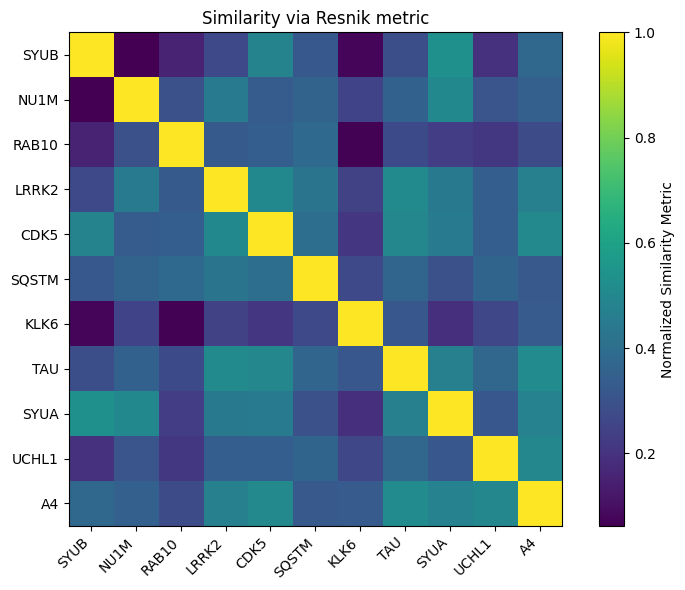

In [6]:
protein_similarity_heatmap_scaled(prot_to_go, resnik_bma, "Similarity via Resnik metric")

In [7]:
# Da qui cercherò delle correlazioni nel cluster di proteine altamente connesse trovate nella PPI di PD.
# Preprocessing: selezionare solo le colonne utili (nome e GOs)

import pandas as pd

file_path = f'{networks_base_path}/Highly Connected Nodes (PD).csv'
useful_columns = ['Entry Name', 'Gene Ontology IDs',
                  'Gene Ontology (biological process)', 'Gene Ontology (cellular component)', 'Gene Ontology (molecular function)']
highly_connected_nodes = pd.read_csv(file_path)[useful_columns]
for column in useful_columns:
    if column != 'Entry Name':
        highly_connected_nodes[column] = highly_connected_nodes[column].fillna('').str.split(';')
        if column != 'Gene Ontology IDs':
            highly_connected_nodes[column] = highly_connected_nodes[column].apply(lambda x: [m for m in pd.Series(x).str.extract(r'(GO:\d+)')[0].dropna()])
    else:
        highly_connected_nodes[column] = highly_connected_nodes[column].str.replace('_HUMAN', '')

highly_connected_nodes

,Entry Name,Gene Ontology IDs,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function)
0,NDUV2,"[GO:0005739, GO:0005743, GO:0006120, GO:000...","[GO:0009060, GO:0048738, GO:0006120, GO:000739...","[GO:0005743, GO:0005739, GO:0045271]","[GO:0051537, GO:0009055, GO:0046872, GO:0008137]"
1,NDUAC,"[GO:0005739, GO:0005743, GO:0005829, GO:000...","[GO:0009060, GO:0042775, GO:0032981, GO:004277...","[GO:0005829, GO:0005743, GO:0005739, GO:0045271]",[GO:0008137]
2,NU6M,"[GO:0005739, GO:0005743, GO:0006120, GO:000...","[GO:0009060, GO:0006120, GO:0032981, GO:004277...","[GO:0005743, GO:0005739]",[GO:0008137]
3,TIDC1,"[GO:0005654, GO:0005739, GO:0005743]",[],"[GO:0005743, GO:0005739, GO:0005654]",[]
4,NDUAB,"[GO:0005739, GO:0005743, GO:0009060, GO:003...","[GO:0009060, GO:0032981, GO:0042776]","[GO:0005743, GO:0005739, GO:0045271]",[]
5,NDUB3,"[GO:0005739, GO:0005743, GO:0006120, GO:000...","[GO:0009060, GO:0006120, GO:0032981, GO:0042776]","[GO:0005743, GO:0005739, GO:0045271]",[GO:0008137]
6,NDUA6,"[GO:0005739, GO:0005743, GO:0006120, GO:000...","[GO:0009060, GO:0006120, GO:0032981, GO:004277...","[GO:0005743, GO:0031966, GO:0005739, GO:0045271]",[GO:0008137]
7,NDUA1,"[GO:0005739, GO:0005743, GO:0006120, GO:000...","[GO:0009060, GO:0006120, GO:0032981, GO:0042776]","[GO:0005743, GO:0031966, GO:0005739, GO:0045271]",[GO:0008137]
8,NDUS2,"[GO:0005654, GO:0005739, GO:0005743, GO:000...","[GO:0009060, GO:0071453, GO:0042063, GO:004277...","[GO:0005743, GO:0005759, GO:0005739, GO:000565...","[GO:0051539, GO:0009055, GO:0046872, GO:005128..."
9,NDUS1,"[GO:0005739, GO:0005743, GO:0005758, GO:000...","[GO:0009060, GO:0045333, GO:0006120, GO:003298...","[GO:0005743, GO:0005758, GO:0005759, GO:000573...","[GO:0051537, GO:0051539, GO:0009055, GO:004687..."


In [8]:
def create_go_dataframe(df, go_column):
    """
    Dato il dataframe in input che avrà associato ad ogni proteina (nella prima colonna) una lista di GO (nella colonna go_column)
    viene costruito un dataframe dove ogni GO (della colonna go_column) è associato ad una lista di proteine.
    """
    go_dict = {}
    for _, row in df.iterrows():
        entry_name = row['Entry Name']
        go_list = row[go_column]
        for go in go_list:
            if go:
                if go not in go_dict:
                    go_dict[go] = []
                go_dict[go].append(entry_name)
    return pd.DataFrame({'GO': go_dict.keys(), 'Proteins': go_dict.values()})

go_ids_df = create_go_dataframe(highly_connected_nodes, 'Gene Ontology IDs')
bp_df = create_go_dataframe(highly_connected_nodes, 'Gene Ontology (biological process)')
cc_df = create_go_dataframe(highly_connected_nodes, 'Gene Ontology (cellular component)')
mf_df = create_go_dataframe(highly_connected_nodes, 'Gene Ontology (molecular function)')

def calculate_go_statistics(go_df):
    """
    Arricchisce il dataframe "go_df" con le statistiche di frequenza e percentuale.
    """
    go_df['Frequency'] = go_df['Proteins'].apply(len)
    total_go_count = go_df['Frequency'].sum()
    go_df['Percentage'] = (go_df['Frequency'] / total_go_count) * 100
    return go_df, total_go_count

# Calcolo delle statistiche per i 4 dataframe
go_ids_stats, total_go_ids = calculate_go_statistics(go_ids_df)
bp_stats, total_bp = calculate_go_statistics(bp_df)
cc_stats, total_cc = calculate_go_statistics(cc_df)
mf_stats, total_mf = calculate_go_statistics(mf_df)


# go_ids_stats.to_csv(f'{output_path}/all_go_frequencies.csv')
# bp_stats.to_csv(f'{output_path}/biological_processes_go_frequencies.csv')
# cc_stats.to_csv(f'{output_path}/cellular_component_go_frequencies.csv')
# mf_stats.to_csv(f'{output_path}/molecular_function_go_frequencies.csv')

In [9]:
# Trova le GO più frequenti (che costituiscono il 70% delle interazioni) 
def extract_most_frequent(df, coverage):
    temporary_df = df.copy()
    
    temporary_df = temporary_df.sort_values(by='Frequency', ascending=False)
    temporary_df['Cumulative Percentage'] = temporary_df['Percentage'].cumsum()
    
    selected = temporary_df[temporary_df['Cumulative Percentage'] <= coverage]
    return selected.drop('Cumulative Percentage', axis=1)


COVERAGE = 70
most_frequent_all = extract_most_frequent(go_ids_stats, COVERAGE)
most_frequent_bp = extract_most_frequent(bp_stats, COVERAGE)
most_frequent_cc = extract_most_frequent(cc_stats, COVERAGE)
most_frequent_mf = extract_most_frequent(mf_stats, COVERAGE)

most_frequent_all.to_csv(f'{output_path}/most_frequent_go_all.csv', index=False)
most_frequent_bp.to_csv(f'{output_path}/most_frequent_go_biological_process.csv',  index=False)
most_frequent_cc.to_csv(f'{output_path}/most_frequent_go_cellular_component.csv',  index=False)
most_frequent_mf.to_csv(f'{output_path}/most_frequent_go_molecular_function.csv',  index=False)

In [10]:
# Output tabella di associazione Nome proteina - informazioni (nome dei geni, id vari)

file_path = f'{networks_base_path}/Highly Connected Nodes (PD).csv'
useful_columns = ['Entry Name', 'Entry', 'Gene Names', 'name', 'Protein names']

ds = pd.read_csv(file_path)[useful_columns]
ds['Entry Name'] = ds['Entry Name'].str.replace('_HUMAN', '')
ds = ds.rename({'Entry': 'UniProtID', 'name': 'StringID'}, axis=1)
ds.to_csv(f'{output_path}/protein_info.csv', index=False)


In [11]:
# Funzioni per fare associazione termine GO e significato

def parse_obo(file_path):
    """
    Legge un file .obo e crea un dizionario dei termini GO.
    Se un termine è obsoleto e ha un 'replaced_by', salva il riferimento.
    """
    go_terms = {}
    obsolete_terms = {}

    with open(file_path, 'r', encoding='utf-8') as file:
        term = {}
        for line in file:
            line = line.strip()
            if line == "[Term]":  # Inizio di un nuovo termine GO
                if "id" in term:
                    go_terms[term["id"]] = term  # Salva il termine precedente
                term = {}  # Reset del dizionario per il nuovo termine
            elif line.startswith("id: "):
                term["id"] = line.split(": ", 1)[1]
            elif line.startswith("name: "):
                term["name"] = line.split(": ", 1)[1]
            elif line.startswith("is_obsolete: true"):
                term["is_obsolete"] = True
            elif line.startswith("replaced_by: "):
                term["replaced_by"] = line.split(": ", 1)[1]
                obsolete_terms[term["id"]] = term["replaced_by"]  # Mappa il vecchio ID a quello nuovo

        if "id" in term:  # Salva l'ultimo termine nel file
            go_terms[term["id"]] = term

    return go_terms, obsolete_terms


def get_go_name(go_id, go_terms, obsolete_terms):
    """
    Dato un ID GO, restituisce il nome corrispondente.
    Se l'ID è obsoleto, segue il riferimento 'replaced_by' fino a trovare un ID valido.
    """
    checked_ids = set()
    while go_id in obsolete_terms:
        if go_id in checked_ids:  # Evita loop infiniti
            return f"Errore: ciclo di sostituzioni per {go_id}"
        checked_ids.add(go_id)
        go_id = obsolete_terms[go_id]  # Passa al termine rimpiazzo

    return go_terms.get(go_id, {}).get("name", f"ID {go_id} non trovato")

In [16]:
# Faccio un dataframe che associa ad ogni go il suo significato

go_terms, obsolete_terms = parse_obo(f'{enrichment_base_path}/go-basic.obo')

go_set = set()
for go_list in highly_connected_nodes["Gene Ontology IDs"].dropna():
    go_set.update([go.strip() for go in go_list])
go_set = sorted(go_set)

go_name_data = {
    "GO": go_set,
    "Name": [get_go_name(go_id, go_terms, obsolete_terms) for go_id in go_set]
}

pd.DataFrame(go_name_data).set_index('GO').to_csv(f'{output_path}/go_meaning.csv')